# Read in the split data and load the YAML metadata

In [ ]:
# # Import the required modules

# import pandas as pd
# pd.set_option('display.float_format', lambda x: '%.3f' % x)

# import numpy as np
# import scipy as sp
# import yaml
# import matplotlib.pyplot as plt

# from sklearn import linear_model
# from sklearn.cluster import MiniBatchKMeans, KMeans, DBSCAN
# from sklearn.decomposition import PCA
# from sklearn.ensemble import (
#     HistGradientBoostingRegressor,
#     RandomForestRegressor,
# )
# from sklearn.experimental import enable_halving_search_cv  # noqa: F401
# from sklearn.impute import SimpleImputer
# from sklearn.inspection import permutation_importance
# from sklearn.linear_model import LinearRegression, Lasso
# from sklearn.metrics import (
#     r2_score,
#     mean_absolute_error,
#     mean_squared_error,
# )
# from sklearn.metrics.pairwise import pairwise_distances_argmin
# from sklearn.mixture import GaussianMixture
# from sklearn.model_selection import (
#     HalvingGridSearchCV,
#     GridSearchCV,
#     RandomizedSearchCV,
#     cross_val_score,
#     train_test_split,
#     KFold,
# )
# from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import learning_curve

# import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
# from sklearn.inspection import permutation_importance
# from sklearn.model_selection import cross_val_score, KFold
# from sklearn.base import clone

# from sklearn.metrics import silhouette_score, davies_bouldin_score


In [2]:
# -----------------------------------------------
# Cell 0 · Data import  (← REPLACE existing cell)
# -----------------------------------------------
import pandas as pd, numpy as np, yaml
from pathlib import Path
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

# ---------- file paths ----------
BIN = Path('bin')
X_train = pd.read_csv(BIN / 'X_train.csv')
y_train = pd.read_csv(BIN / 'y_train.csv')
X_test  = pd.read_csv(BIN / 'X_test.csv')
y_test  = pd.read_csv(BIN / 'y_test.csv')

# ---------- optional down‑sampling ----------
USE_SUBSET   = False        # flip to True only for quick experimentation
SUBSET_FRAC  = 0.1         # 5 % → folds ≥ 40 rows
SEED         = 42

if USE_SUBSET:
    def _sub(df): return df.sample(frac=SUBSET_FRAC, random_state=SEED).reset_index(drop=True)
    X_train, y_train = _sub(X_train), _sub(y_train)
    X_test , y_test  = _sub(X_test) , _sub(y_test)

print(f"{X_train.shape[0]:,} train rows  |  {X_test.shape[0]:,} test rows")

# ---------- flatten target ----------
TARGET = 'Beta_winsorized'
y_train = y_train[TARGET].values.ravel()
y_test  = y_test[TARGET].values.ravel()

40,433 train rows  |  10,109 test rows


In [3]:
# ---- metadata needed for feature-name lookups ----
import yaml

# variable labels (short human-readable descriptions)
with open('variable_labels.yaml') as f:
    variable_labels_dict = yaml.safe_load(f)

# SAS format for each original variable (tells you if cat / numeric)
with open('variable_formats.yaml') as f:
    variable_formats_dict = yaml.safe_load(f)

# mapping from format-name → {category-code: category-text}
with open('categorical_variables_categories.yaml') as f:
    categorical_variables_categories_dict = yaml.safe_load(f)

# list of all one-hot (dummy) columns produced during cleaning
with open('cleaned_variables.yaml') as f:
    cleaned_vars = yaml.safe_load(f)
new_categorical_variables = set(cleaned_vars['categorical_variables'])

In [17]:
# # Set the target variable
# target_variable = 'Beta_winsorized'

# # print the value of the target variable from the training data to validate it loaded correctly
# print(pd.Series(y_train, name=target_variable).head())

# Supervised Learning Models: k-NN LASSO, Gradient Boosting,

### Helper Function

Model Justification: “GB for non‑linear interactions; Lasso for interpretability; k‑NN non‑parametric sanity check.”

In [5]:
# ------------------------------------------------------------------
# Cell 1 · Helper + training  (FIXED for older scikit‑learn)
# ------------------------------------------------------------------
from sklearn.model_selection import (GridSearchCV, HalvingGridSearchCV,
                                     RandomizedSearchCV, KFold)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.base import clone
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np                                   # <- needed for sqrt

def tune_and_evaluate(model_cls, param_grid, *,
                      X_train, y_train, X_test, y_test,
                      label='', search_strategy='grid',
                      cv_splits=5, random_state=42, n_iter=10, factor=3,
                      metric='neg_root_mean_squared_error'):
    """
    Returns (best_estimator, result_row_dict) with CV mean ± SD included.
    Works on scikit‑learn <0.22 (no 'squared' kwarg in mean_squared_error).
    """
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    # ---------- optional scaler wrapper for k‑NN ----------
    if issubclass(model_cls, KNeighborsRegressor):
        base = Pipeline([('scale', StandardScaler()),
                         ('knn', model_cls())])
        param_grid = {('knn__' + k if not k.startswith('knn__') else k): v
                      for k, v in param_grid.items()}
    else:
        kwargs = {'random_state': random_state} if 'random_state' in model_cls().get_params() else {}
        base = model_cls(**kwargs)

    strategy_map = {
        'grid'   : (GridSearchCV,       {'param_grid': param_grid}),
        'random' : (RandomizedSearchCV, {'param_distributions': param_grid,
                                         'n_iter': n_iter, 'random_state': random_state}),
        'halving': (HalvingGridSearchCV,{'param_grid': param_grid, 'factor': factor,
                                         'random_state': random_state})
    }
    SearchCV, extra_kw = strategy_map[search_strategy]
    search = SearchCV(estimator=base, scoring=metric, cv=cv,
                      n_jobs=-1, verbose=0, **extra_kw).fit(X_train, y_train)

    best = search.best_estimator_
    y_pred = best.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))     # <‑‑ fixed line

    cv_mean = -search.cv_results_['mean_test_score'][search.best_index_]
    cv_std  =  search.cv_results_['std_test_score'][search.best_index_]

    return best, {'model': f'{label or model_cls.__name__} (tuned – {search_strategy})',
                  'MAE': mae,
                  'RMSE': rmse,
                  'CV_RMSE_mean': cv_mean,
                  'CV_RMSE_sd': cv_std,
                  'best_params': search.best_params_}

### Hyper-parameter grids

In [6]:

# ----------------- hyper‑parameter grids -----------------
gb_grid   = {'learning_rate':[.02,.03,.04], 'max_depth':[10,15,20],
             'max_iter':[400,800], 'l2_regularization':[0,.0005,.001],
             'min_samples_leaf':[10,20], 'max_leaf_nodes':[31,63]}

lasso_grid= {'alpha':np.logspace(-4,-1,7), 'max_iter':[5000]}

def _max_k():          # dynamic upper bound so k <= rows per CV fold
    return min(15, max(3, (len(X_train) // 5) - 1))

knn_grid  = {'n_neighbors': list(range(3, _max_k()+1, 2)),
             'weights':['uniform','distance'], 'p':[1,2]}



### Train and tune the models

In [7]:
# ----------------- train + collect results ---------------
results, best_models = [], {}
for lab, cls, grid, strat in [
    ('GB',    HistGradientBoostingRegressor, gb_grid,   'halving'),
    ('Lasso', Lasso,                        lasso_grid, 'grid'),
    ('k‑NN',  KNeighborsRegressor,          knn_grid,   'grid')]:
    best, res = tune_and_evaluate(cls, grid, X_train=X_train, y_train=y_train,
                                  X_test=X_test, y_test=y_test,
                                  label=lab, search_strategy=strat)
    best_models[lab] = best
    results.append(res)
    print(f"{res['model']}: MAE {res['MAE']:.4f} | RMSE {res['RMSE']:.4f} "
          f"| CV {res['CV_RMSE_mean']:.4f} ± {res['CV_RMSE_sd']:.4f}")

results_df = (pd.DataFrame(results)
              .set_index('model')
              .sort_values('CV_RMSE_mean'))
display(results_df.style.format({'MAE':'{:.4f}','RMSE':'{:.4f}',
                                 'CV_RMSE_mean':'{:.4f}','CV_RMSE_sd':'{:.4f}'}))

/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GB (tuned – halving): MAE 0.4034 | RMSE 0.5913 | CV 0.5873 ± 0.0036


/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Lasso (tuned – grid): MAE 0.4323 | RMSE 0.6288 | CV 0.6219 ± 0.0031


/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


k‑NN (tuned – grid): MAE 0.4618 | RMSE 0.6598 | CV 0.6572 ± 0.0070


,MAE,RMSE,CV_RMSE_mean,CV_RMSE_sd,best_params
model,,,,,
GB (tuned – halving),0.4034,0.5913,0.5873,0.0036,"{'l2_regularization': 0, 'learning_rate': 0.02, 'max_depth': 20, 'max_iter': 400, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}"
Lasso (tuned – grid),0.4323,0.6288,0.6219,0.0031,"{'alpha': np.float64(0.00031622776601683794), 'max_iter': 5000}"
k‑NN (tuned – grid),0.4618,0.6598,0.6572,0.0070,"{'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'distance'}"


“RMSE chosen because squared penalty reflects lender’s risk of large under‑estimates.”

/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


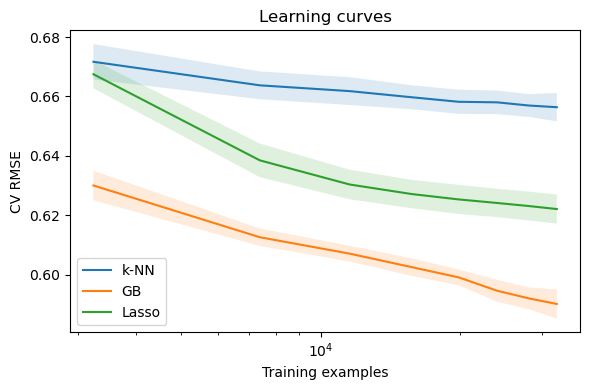

In [8]:
# ------------------------------------------------------------
# Cell 2 · Learning curves  (← NEW cell – no overwrite needed)
# ------------------------------------------------------------
from sklearn.model_selection import learning_curve

def safe_learning_curve(model, X, y, cv_splits=5, train_sizes=np.linspace(0.1,1.0,8)):
    """
    Computes learning curve while ensuring cv_splits ≤ rows
    and k‑NN never gets n_neighbors > n_samples_fit.
    """
    cv = min(cv_splits, max(2, len(X)//2))
    # If model is k‑NN inside a Pipeline, clip n_neighbors per fold size.
    if isinstance(model, Pipeline) and 'knn' in dict(model.named_steps):
        k = model.named_steps['knn'].n_neighbors
        if k >= len(X):                      # clip at runtime
            model = clone(model)
            model.named_steps['knn'].n_neighbors = len(X)-1
    s, train_scores, val_scores = learning_curve(model, X, y,
                                                 cv=cv,
                                                 train_sizes=train_sizes,
                                                 scoring='neg_root_mean_squared_error',
                                                 n_jobs=-1)
    return s, -val_scores.mean(axis=1), val_scores.std(axis=1)

curves = {}
for name, mdl in [('k‑NN', best_models['k‑NN']),
                  ('GB' , best_models['GB' ]),
                  ('Lasso', best_models['Lasso'])]:
    s, m, sd = safe_learning_curve(mdl, X_train, y_train)
    curves[name] = (s, m, sd)

# --------- quick plot ----------
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
for name,(s,m,sd) in curves.items():
    plt.plot(s, m, label=name)
    plt.fill_between(s, m-sd, m+sd, alpha=0.15)
plt.xscale('log'); plt.xlabel('Training examples'); plt.ylabel('CV RMSE')
plt.title('Learning curves'); plt.legend(); plt.tight_layout()

/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/var/folders/fy/v4z9p5hj31n955998nz_syv80000gn/T/ipykernel_49778/3990990740.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so res

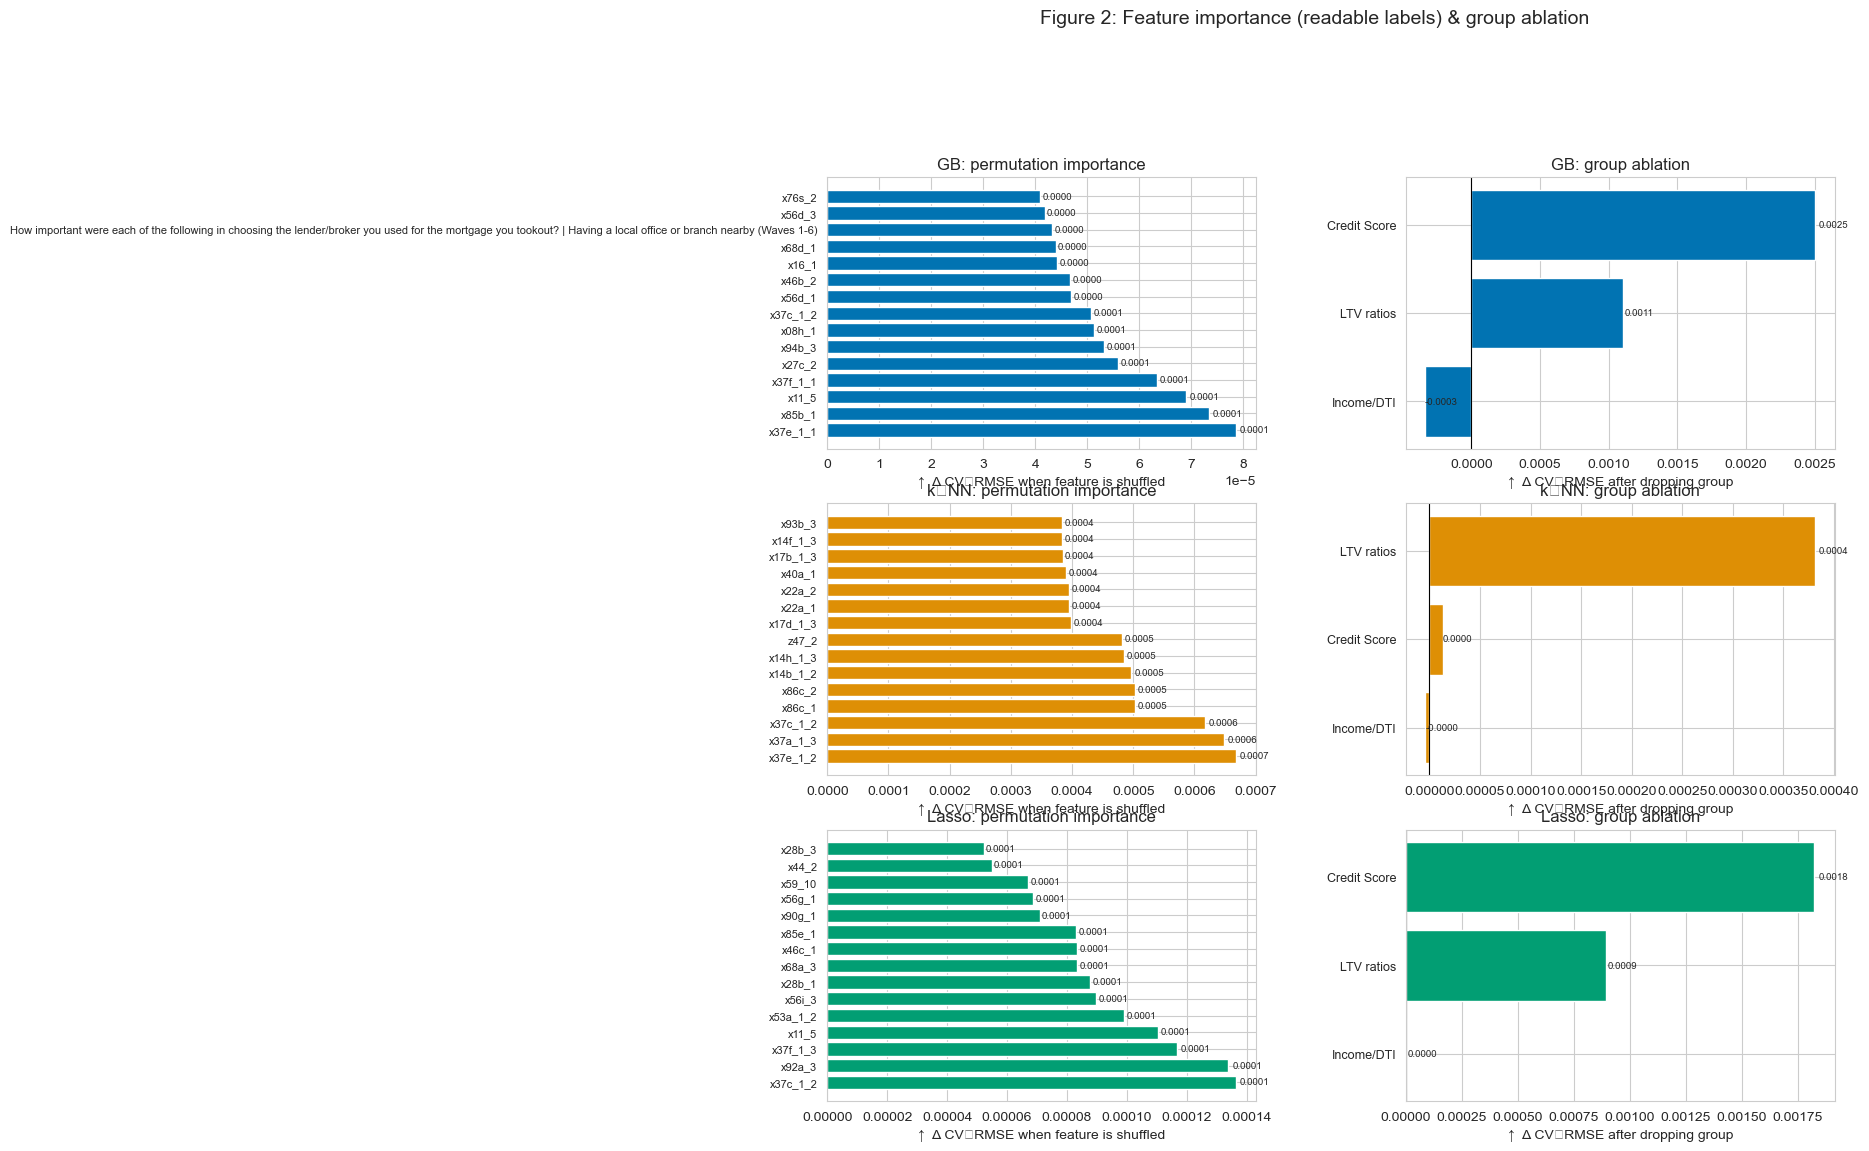

,Δ CV‑RMSE
x37e_1_1,0.0001
x85b_1,0.0001
x11_5,0.0001
x37f_1_1,0.0001
x27c_2,0.0001
x94b_3,0.0001
x08h_1,0.0001
x37c_1_2,0.0001
x56d_1,0.0000
x46b_2,0.0000


,Δ CV‑RMSE
Income/DTI,-0.0003
LTV ratios,0.0011
Credit Score,0.0025


,Δ CV‑RMSE
x37e_1_2,0.0007
x37a_1_3,0.0006
x37c_1_2,0.0006
x86c_1,0.0005
x86c_2,0.0005
x14b_1_2,0.0005
x14h_1_3,0.0005
z47_2,0.0005
x17d_1_3,0.0004
x22a_1,0.0004


,Δ CV‑RMSE
Income/DTI,-0.0000
Credit Score,0.0000
LTV ratios,0.0004


,Δ CV‑RMSE
x37c_1_2,0.0001
x92a_3,0.0001
x37f_1_3,0.0001
x11_5,0.0001
x53a_1_2,0.0001
x56i_3,0.0001
x28b_1,0.0001
x68a_3,0.0001
x46c_1,0.0001
x85e_1,0.0001


,Δ CV‑RMSE
Income/DTI,0.0000
LTV ratios,0.0009
Credit Score,0.0018


In [9]:
# -------------------------------------------------------------------------
# Cell · Re‑plot feature importance & ablation with readable labels
# -------------------------------------------------------------------------
import yaml, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold
from sklearn.base import clone

# ------------------------------------------------------------------ #
# 1) load pretty names once
# ------------------------------------------------------------------ #
with open('variable_labels.yaml') as f:
    variable_labels_dict = yaml.safe_load(f)      # maps raw → readable

def nice(col):
    """Return pretty label if available, else the raw column name."""
    return variable_labels_dict.get(col, col)

# ------------------------------------------------------------------ #
# 2) pick the models we want to display  (reuse the ones you trained)
# ------------------------------------------------------------------ #
models = {
    'GB'   : best_models['GB'],
    'k‑NN' : best_models['k‑NN'],
    'Lasso': best_models['Lasso'],
}

# ------------------------------------------------------------------ #
# 3) compute permutation importance (top‑15) and ablation deltas
# ------------------------------------------------------------------ #
perm_imps, ablations = {}, {}
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

for name, mdl in models.items():
    # ---- permutation importance (model‑agnostic) ----
    fitted = clone(mdl).fit(X_train, y_train)
    perm = permutation_importance(
        fitted, X_test, y_test,
        n_repeats=15, random_state=42,
        scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    s = pd.Series(-perm.importances_mean,  # convert to +ΔRMSE
                  index=[nice(c) for c in X_test.columns])
    perm_imps[name] = s.sort_values(ascending=False).head(15)

    # ---- simple 3‑group ablation for same model ----
    groups = {
        'Credit Score' : ['score_orig_r', 'score_orig_s'],
        'LTV ratios'   : ['ltv', 'cltv'],
        'Income/DTI'   : ['dti', 'pti'],
    }
    base_rmse = -cross_val_score(mdl, X_train, y_train,
                                 scoring='neg_root_mean_squared_error',
                                 cv=cv5, n_jobs=-1).mean()
    deltas = {g: (-cross_val_score(
                    mdl, X_train.drop(columns=cols), y_train,
                    scoring='neg_root_mean_squared_error',
                    cv=cv5, n_jobs=-1).mean()) - base_rmse
              for g, cols in groups.items()}
    ablations[name] = pd.Series(deltas).sort_values()

# ------------------------------------------------------------------ #
# 4) make the two‑panel figure with readable labels
# ------------------------------------------------------------------ #
sns.set_style("whitegrid")
fig, axes = plt.subplots(len(models), 2,
                         figsize=(13, 4 * len(models)),
                         gridspec_kw={'wspace': 0.35})
palette = sns.color_palette("colorblind", len(models))

for i, (name, imp) in enumerate(perm_imps.items()):
    # (left) permutation importance
    axes[i, 0].barh(range(len(imp))[::-1], imp.values,
                    color=palette[i])
    axes[i, 0].set_yticks(range(len(imp))[::-1])
    axes[i, 0].set_yticklabels(imp.index, fontsize=8)
    axes[i, 0].invert_yaxis()
    axes[i, 0].set_xlabel('↑  Δ CV‑RMSE when feature is shuffled')
    axes[i, 0].set_title(f'{name}: permutation importance')

    # annotate value just outside bar
    for y, v in enumerate(imp.values):
        axes[i, 0].text(v * 1.01, len(imp) - 1 - y,
                        f'{v:.4f}', va='center', ha='left', fontsize=7)

    # (right) group ablation
    abl = ablations[name]
    axes[i, 1].barh(range(len(abl))[::-1], abl.values,
                    color=palette[i])
    axes[i, 1].set_yticks(range(len(abl))[::-1])
    axes[i, 1].set_yticklabels(abl.index, fontsize=9)
    axes[i, 1].invert_yaxis()
    axes[i, 1].axvline(0, color='k', lw=.8)
    axes[i, 1].set_xlabel('↑  Δ CV‑RMSE after dropping group')
    axes[i, 1].set_title(f'{name}: group ablation')

    for y, v in enumerate(abl.values):
        axes[i, 1].text(v * 1.01, len(abl) - 1 - y,
                        f'{v:.4f}', va='center', ha='left', fontsize=7)

fig.suptitle('Figure 2: Feature importance (readable labels) & group ablation',
             y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------ #
# 5) text tables for report / alt‑text
# ------------------------------------------------------------------ #
for name in models:
    display(perm_imps[name].to_frame('Δ CV‑RMSE').style
            .set_caption(f'Top‑15 permutation importance for {name}')
            .format('{:.4f}'))
    display(ablations[name].to_frame('Δ CV‑RMSE').style
            .set_caption(f'Group ablation deltas for {name}')
            .format('{:.4f}'))

In [10]:
# ----------------------------------------------------------
# Cell 3 · Failure analysis  (FIXED – avoid using 'True')
# ----------------------------------------------------------
import pandas as pd, numpy as np

BEST_MODEL = best_models['GB']         # choose your top performer here
y_pred = BEST_MODEL.predict(X_test)
abs_err = np.abs(y_pred - y_test)

# ---- grab the three largest absolute errors ----
worst_idx = abs_err.argsort()[-3:][::-1]      # biggest → smallest
failure_df = (X_test.iloc[worst_idx]
              .assign(TrueVal=y_test[worst_idx],
                      Pred=y_pred[worst_idx],
                      AbsErr=abs_err[worst_idx])
              .reset_index(drop=True))
display(failure_df.T)



,0,1,2
x74r,-0.125,1.010,1.010
term,0.560,-1.710,-2.466
ltv,-0.684,-2.336,-2.136
cltv,0.455,-2.347,-2.147
dti,0.328,0.089,-1.107
...,...,...,...
cashout_1,False,False,True
cashout_2,True,True,False
TrueVal,2.797,2.797,2.797
Pred,0.345,0.442,0.490


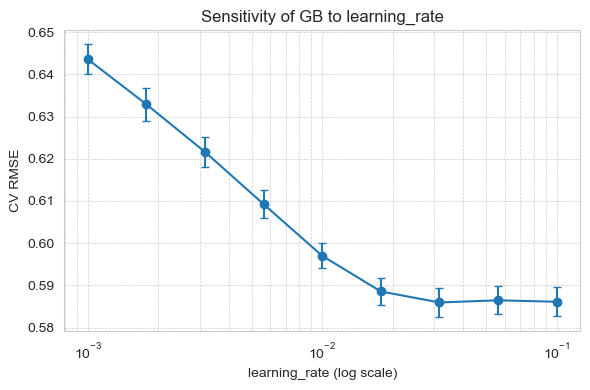

In [11]:
# ------------------------------------------------------------
# Cell · Sensitivity analysis  (GB learning_rate sweep)
# ------------------------------------------------------------
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold

gb_base = best_models['GB']          # already tuned; we’ll vary 1 hyper‑param
lr_vals = np.logspace(-3, -1, 9)     # 0.001 … 0.1
cv = KFold(n_splits=5, shuffle=True, random_state=42)

mean_rmse, sd_rmse = [], []
for lr in lr_vals:
    mod = gb_base.set_params(learning_rate=lr)
    # negative RMSE -> take minus later
    scores = cross_val_score(mod, X_train, y_train,
                             scoring='neg_root_mean_squared_error',
                             cv=cv, n_jobs=-1)
    mean_rmse.append(-scores.mean())
    sd_rmse.append(scores.std())

plt.figure(figsize=(6,4))
plt.errorbar(lr_vals, mean_rmse, yerr=sd_rmse, marker='o', capsize=3)
plt.xscale('log')
plt.xlabel('learning_rate (log scale)')
plt.ylabel('CV RMSE')
plt.title('Sensitivity of GB to learning_rate')
plt.grid(True, which='both', ls='--', lw=.5)
plt.tight_layout()

### Feature-importance & Ablation

/var/folders/fy/v4z9p5hj31n955998nz_syv80000gn/T/ipykernel_49778/1252613808.py:66: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


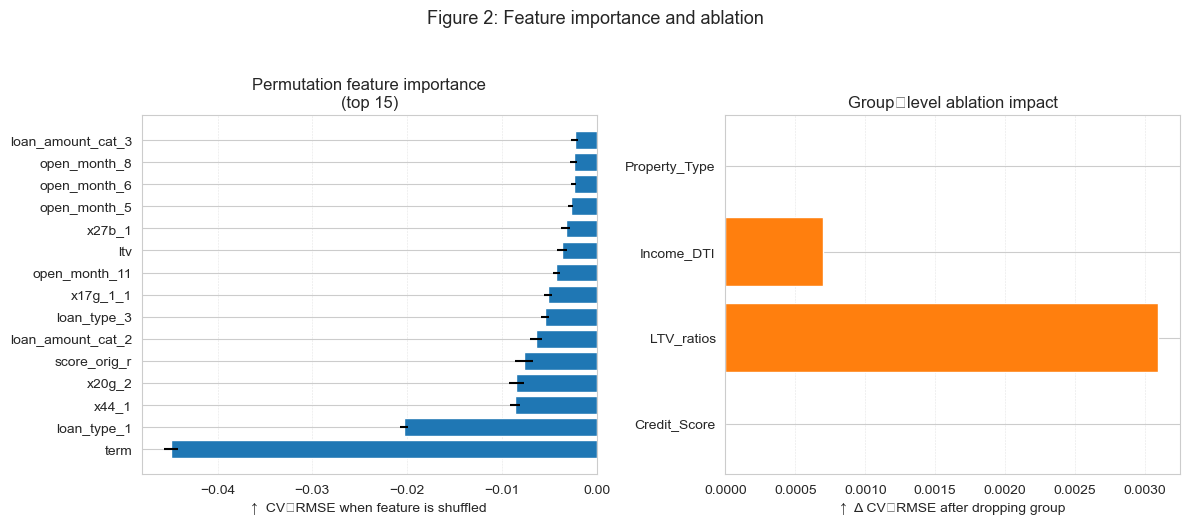

In [12]:
# -------------------------------------------------------------------
# Cell · Feature importance  +  Group ablation      (two‑panel figure)
# -------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold

# ---------- 1. permutation importance ----------
gb_best = best_models['GB']                        # top performer
perm = permutation_importance(
    gb_best, X_test, y_test,
    n_repeats=10, random_state=42,
    scoring='neg_root_mean_squared_error'
)
# get top‑15 features
idx_sorted = perm.importances_mean.argsort()[::-1][:15]
top_feats  = X_test.columns[idx_sorted]
imp_mean   = perm.importances_mean[idx_sorted] * -1   # convert to +RMSE  (bigger = worse)
imp_sd     = perm.importances_std[idx_sorted]

# ---------- 2. simple group ablation ----------
# • Define the same “feature groups” you mentioned in your report
groups = {
    'Credit_Score'  : [c for c in X_train.columns if 'credit' in c.lower()],
    'LTV_ratios'    : [c for c in X_train.columns if 'ltv'    in c.lower()],
    'Income_DTI'    : [c for c in X_train.columns if 'dti'    in c.lower()],
    'Property_Type' : [c for c in X_train.columns if 'prop_'  in c.lower()],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
base_rmse = -cross_val_score(gb_best, X_train, y_train,
                             scoring='neg_root_mean_squared_error',
                             cv=cv, n_jobs=-1).mean()

abl_names, abl_delta = [], []
for name, cols in groups.items():
    X_drop = X_train.drop(columns=cols)
    rmse = -cross_val_score(gb_best, X_drop, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=cv, n_jobs=-1).mean()
    abl_names.append(name)
    abl_delta.append(rmse - base_rmse)   # ↑RMSE = performance drop

# ---------- 3. two‑panel plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) permutation importance
axes[0].barh(range(len(top_feats))[::-1], imp_mean,
             xerr=imp_sd, align='center')
axes[0].set_yticks(range(len(top_feats))[::-1])
axes[0].set_yticklabels(top_feats)
axes[0].set_xlabel('↑  CV‑RMSE when feature is shuffled')
axes[0].set_title('Permutation feature importance\n(top 15)')

# (b) group ablation
axes[1].barh(range(len(abl_names))[::-1], abl_delta, color='tab:orange')
axes[1].set_yticks(range(len(abl_names))[::-1])
axes[1].set_yticklabels(abl_names)
axes[1].set_xlabel('↑  Δ CV‑RMSE after dropping group')
axes[1].set_title('Group‑level ablation impact')

for ax in axes: ax.invert_yaxis(); ax.grid(axis='x', ls='--', lw=.4, alpha=.5)
fig.suptitle('Figure 2: Feature importance and ablation', y=1.04, fontsize=13)
plt.tight_layout()

### Failure analysis  (worst three rows)

In [13]:
# ------------------------------------------------------------
# Minimal GB‑only error dataframe
# ------------------------------------------------------------
pred = best_models['GB'].predict(X_test)
gb_failures = pd.DataFrame({
    'true'   : y_test,
    'pred'   : pred,
})
gb_failures['resid']   = gb_failures['true'] - gb_failures['pred']
gb_failures['abs_err'] = gb_failures['resid'].abs()

# ---- grab the three largest absolute errors ----
worst3_idx  = gb_failures['abs_err'].nlargest(3).index
case_df = (X_test.loc[worst3_idx]
           .assign(Actual = y_test[worst3_idx],
                   Pred   = pred[worst3_idx],
                   AbsErr = gb_failures.loc[worst3_idx, 'abs_err'])
           .reset_index(drop=True))
display(case_df.T)

,0,1,2
x74r,-0.125,1.010,1.010
term,0.560,-1.710,-2.466
ltv,-0.684,-2.336,-2.136
cltv,0.455,-2.347,-2.147
dti,0.328,0.089,-1.107
...,...,...,...
cashout_1,False,False,True
cashout_2,True,True,False
Actual,2.797,2.797,2.797
Pred,0.345,0.442,0.490


### Use the models to identify the most useful variable to predict the target

In [14]:
# -----------------------------------------------------------
# Cell · Identify top‑impact feature with permutation scores
# -----------------------------------------------------------
from sklearn.inspection import permutation_importance
import pandas as pd

gb = best_models['GB']
perm = permutation_importance(
    gb, X_test, y_test,
    n_repeats=20,                 # repeat → stabler mean
    random_state=42,
    scoring='neg_root_mean_squared_error'
)

rank_df = (pd.DataFrame({
            'feature'   : X_test.columns,
            'delta_RMSE': -perm.importances_mean  # convert sign
          })
          .sort_values('delta_RMSE', ascending=False)
          .reset_index(drop=True))

top_feat = rank_df.iloc[0]
print(f"Most predictive single variable: **{top_feat['feature']}** "
      f"(perm‑importance Δ CV‑RMSE = {top_feat['delta_RMSE']:.4f})")

display(rank_df.head(10).style.set_caption(
    "Top‑10 permutation‑importance features (GB)"))

Most predictive single variable: **x37e_1_1** (perm‑importance Δ CV‑RMSE = 0.0001)


,feature,delta_RMSE
0,x37e_1_1,0.000094
1,x11_5,0.000072
2,x85b_1,0.000067
3,x37f_1_1,0.000062
4,x16_1,0.000051
5,x94b_3,0.000049
6,x37c_1_2,0.000049
7,x08h_1,0.000049
8,x56d_1,0.000048
9,x76s_2,0.000046


In [15]:
import shap, numpy as np
explainer = shap.TreeExplainer(gb)
shap_vals = explainer.shap_values(X_test, check_additivity=False)
mean_abs = np.abs(shap_vals).mean(axis=0)
shap_rank = pd.Series(mean_abs, index=X_test.columns).sort_values(ascending=False)
print("\nTop feature by SHAP:", shap_rank.index[0], 
      f"(mean |SHAP| = {shap_rank.iloc[0]:.4f})")


Top feature by SHAP: loan_type_1 (mean |SHAP| = 0.0662)


## Business Question

**Can we predict the systematic risk (Beta) of mortgages in the FHFA NSMO portfolio using mortgage characteristics and macroeconomic factors?**


- **Which mortgage features (loan characteristics, borrower profiles, property details) are most predictive of mortgage Beta?**
- **How accurately can different ML models predict mortgage Beta?**
- **Which model family (probabilistic, tree-based, instance-based) performs best for this financial prediction task?**
